<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 846 | Val: 205 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[InceptionNet v3] Epoch   1/100 | LR: 1.38e-03 | train loss 3.0399 acc 0.428 | val loss 1.3334 acc 0.439 *


[InceptionNet v3] Epoch   2/100 | LR: 1.38e-03 | train loss 1.6310 acc 0.431 | val loss 1.2488 acc 0.580 *


[InceptionNet v3] Epoch   3/100 | LR: 1.38e-03 | train loss 1.3055 acc 0.571 | val loss 1.3886 acc 0.493


[InceptionNet v3] Epoch   4/100 | LR: 1.38e-03 | train loss 1.3947 acc 0.466 | val loss 1.2783 acc 0.434


...

[InceptionNet v3] Epoch  32/100 | LR: 1.38e-04 | train loss 0.2800 acc 0.897 | val loss 0.4158 acc 0.839


[InceptionNet v3] Epoch  33/100 | LR: 1.38e-04 | train loss 0.2568 acc 0.923 | val loss 0.4493 acc 0.849


[InceptionNet v3] Epoch  34/100 | LR: 1.38e-04 | train loss 0.2733 acc 0.910 | val loss 0.4243 acc 0.839


[InceptionNet v3] Epoch  35/100 | LR: 1.38e-04 | train loss 0.2225 acc 0.933 | val loss 0.4496 acc 0.829


[InceptionNet v3] Epoch  36/100 | LR: 1.38e-04 | train loss 0.2432 acc 0.921 | val loss 0.4642 acc 0.849

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 36.

[InceptionNet v3] Restored best checkpoint (val loss = 0.3732)


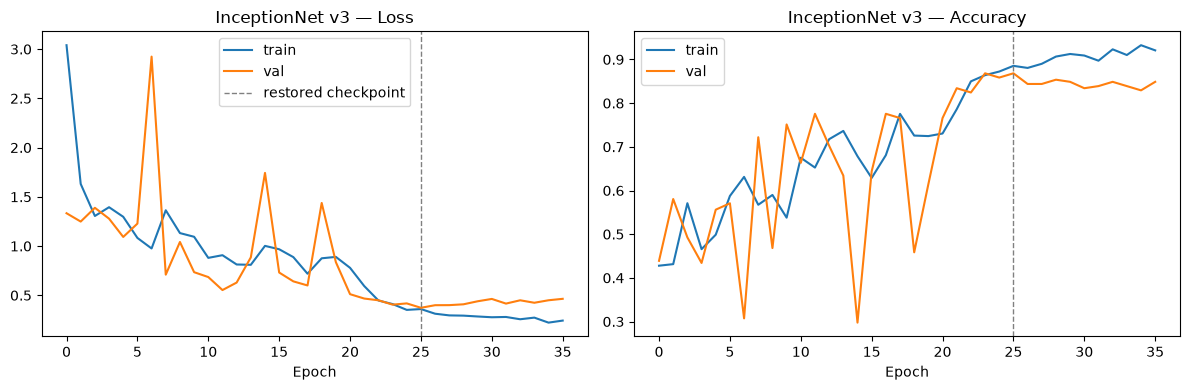

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.619


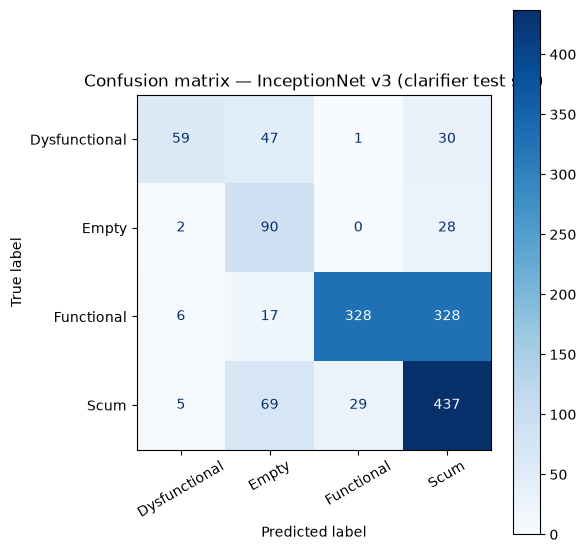

               precision    recall  f1-score   support

Dysfunctional      0.819     0.431     0.565       137
        Empty      0.404     0.750     0.525       120
   Functional      0.916     0.483     0.633       679
         Scum      0.531     0.809     0.641       540

     accuracy                          0.619      1476
    macro avg      0.668     0.618     0.591      1476
 weighted avg      0.725     0.619     0.621      1476



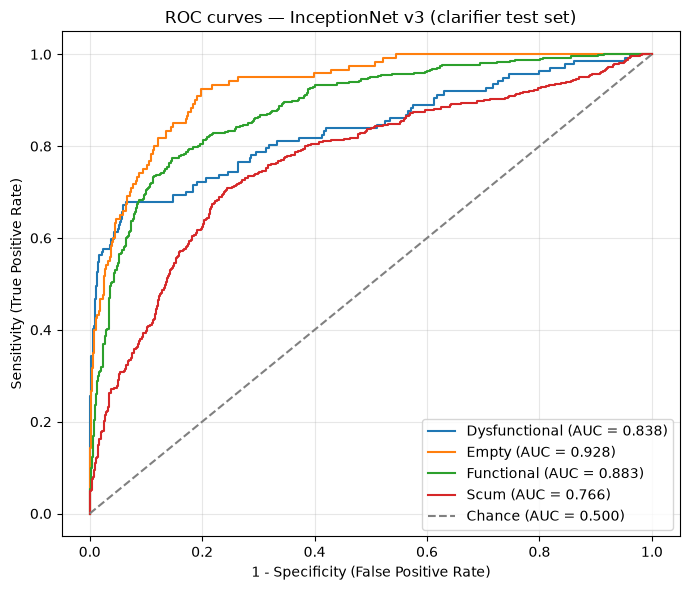

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.838
  Empty          : 0.928
  Functional     : 0.883
  Scum           : 0.766

Mean AUC (over 4/4 classes with test examples): 0.854


(np.float64(0.6192411924119241),
 {'Dysfunctional': 0.8377098063158583,
  'Empty': 0.9281034906588004,
  'Functional': 0.8827303418748139,
  'Scum': 0.7664905824628047})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/clarifier_aug/results_clarifier_inception_v3_CapeFlats.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
